In [1]:
import pandas as pd
import seaborn as sns, matplotlib.pyplot as plt, numpy as np

csvs = [
    'full.csv',
    'small.csv',
    'tiny.csv',
]


mdf = pd.DataFrame()
for csv in csvs:
    df = pd.read_csv('data/' + csv)
    df['Model size'] = csv.split('.')[0]
    mdf = pd.concat([mdf, df], ignore_index=True)

mdf

mdf['Percent loss from equivariance error'] = mdf['equivar_loss_term_3'] / (mdf['equivar_loss_term_3'] + mdf['equivar_loss_term_2'])

In [ ]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

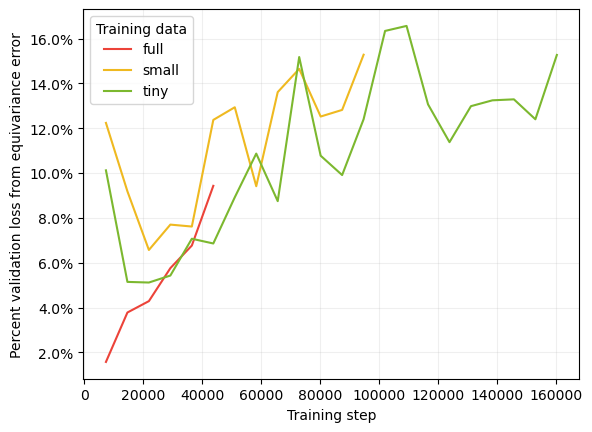

In [3]:
fig, ax = plt.subplots()
sns.lineplot(
    data = mdf,
    x = 'iteration',
    y = 'Percent loss from equivariance error',
    hue = 'Model size',
    palette = {
        'full': '#ec4339',
        'small': '#efb920',
        'tiny': '#7cb82f',
    },
    errorbar = None,
    ax = ax,
)
plt.grid(alpha = 0.2)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Training step')
plt.ylabel('Percent validation loss from equivariance error')
plt.legend(title = 'Training data')

plot_name = 'voxmol-vary-model'

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

import os
os.makedirs('pdfs', exist_ok=True)
os.makedirs('svgs', exist_ok=True)

plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.savefig('svgs/' + plot_name + '.svg', transparent = True)
plt.show()
plt.close()